# Working with complicated dataset

Your name:

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [16]:
### Your code here . . .

import pandas as pd
awk_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

my_columns = ["query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches", " gap  opens", "q.start", "q.end", "s.start", "s.end", "evalue", "bit score", "% positive", "bonds", "publications"]

awk = pd.read_csv(awk_file,
                   skiprows = 7,
                  index_col= "subject acc.ver",
                  header = None,
                  names = my_columns,
                  usecols = my_columns,
                  thousands=",",
                  na_values="-")

awk.drop(columns = "query acc.ver", inplace = True)

awk.head()

,% identity,alignment length,mismatches,gap opens,q.start,q.end,s.start,s.end,evalue,bit score,% positive,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


### Question 2
What is the average number of publications?

In [17]:
### Your code here . . .
print(awk['publications'].mean())

26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [11]:
### Your code here . . .
awk[awk['bonds'] > 15000]

,% identity,alignment length,mismatches,gap opens,q.start,q.end,s.start,s.end,evalue,bit score,% positive,bonds,publications
subject acc.ver,,,,,,,,,,,,,
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3
6G2J_H,100.000,317,0,0,2,318,2,318,0,626,100.00,15663,29
YP_002791042.1,99.057,318,3,0,1,318,1,318,0,625,99.69,15830,37
AGK29634.1,99.057,318,3,0,1,318,1,318,0,623,99.69,17381,14
0806162F,100.000,315,0,0,4,318,1,315,0,622,100.00,17499,43
YP_009112408.1,97.170,318,9,0,1,318,1,318,0,615,99.37,16861,46
YP_001876469.1,96.855,318,10,0,1,318,1,318,0,613,99.06,16274,22
YP_009092269.1,96.226,318,12,0,1,318,1,318,0,610,98.11,16170,47


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

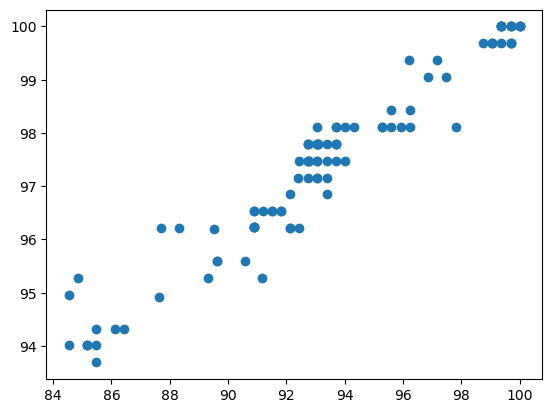

In [8]:
### Your code here . . .
import matplotlib.pyplot as plt
plt.scatter(awk['% identity'], awk['% positive'])
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [26]:
### Your code here . . .
protein_df = pd.read_csv(
    "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
)

awk = awk.reset_index()

awk = awk.merge(
    protein_df,
    how="left",
    left_on="subject acc.ver",
    right_on="Protein"
)

awk = awk.drop(columns=["Protein", "Unnamed: 0"], errors="ignore")
awk = awk.rename(columns={"Source": "Protein source"})
awk = awk.set_index("subject acc.ver")
awk.columns

Index(['% identity', 'alignment length', 'mismatches', ' gap  opens',
       'q.start', 'q.end', 's.start', 's.end', 'evalue', 'bit score',
       '% positive', 'bonds', 'publications', 'Protein source',
       'Protein source'],
      dtype='object')